In [3]:
import numpy as np
import math
import matplotlib.pyplot as plt

In [4]:
To = 12960e3 # N, per tendon
Lo = [10, 35, 60] # initial tendon length
alpha = math.radians(5) # initial angle of tendon with respect to vertical
Aw = 40 * 15 # m^2, water plane area
rho = 1025 # kg/m^3, water density
g = 9.81 # m/s^2, acceleration due to gravity
dx = [math.tan(alpha) * l for l in Lo] # m, FIXED ANGLE
# dx = 5 * np.ones_like(Lo) # m, FIXED EXCURSION
dz = [l * (1 - np.sqrt(1 - (dx[i] / l)**2)) for i, l in enumerate(Lo)]

Fx = math.tan(alpha) * To

print(f'Horizontal force on tendon: {Fx:.1f} N')
print(f'Horizontal force on tendon: {Fx/1e6:.1f} MN')

Kx = [Fx/1e3 / d for d in dx]  # kN/m for each tendon
print('Horizontal stiffness Kx =', [f'{k:.1f}' for k in Kx], 'kN/m')

Horizontal force on tendon: 1133853.1 N
Horizontal force on tendon: 1.1 MN
Horizontal stiffness Kx = ['1296.0', '370.3', '216.0'] kN/m


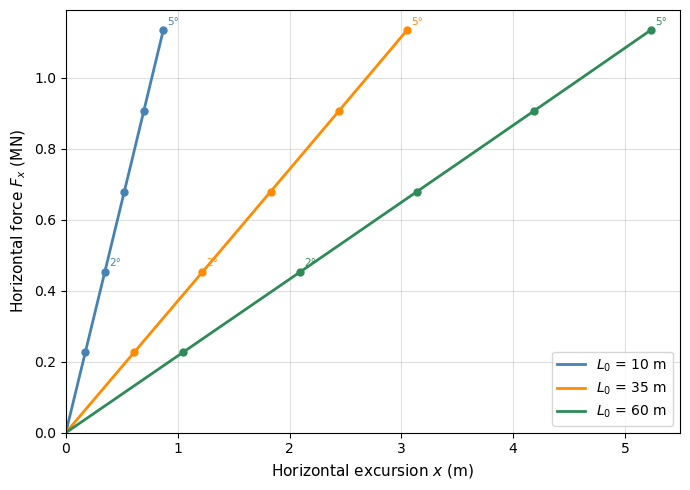

In [5]:
import numpy as np
import matplotlib.pyplot as plt

# Parameters
To = 12960e3        # N, vertical pre-tension per tendon
Lo_list = [10, 35, 60]  # m, cable lengths
colors = ['steelblue', 'darkorange', 'seagreen']
angle_marks_deg = [1, 2, 3, 4, 5]

fig, ax = plt.subplots(figsize=(7, 5))

for Lo, color in zip(Lo_list, colors):
    x_max = Lo * np.sin(np.radians(5))  # max excursion at 5°
    x = np.linspace(0, x_max, 500)
    z = np.sqrt(Lo**2 - x**2)
    Fx = To * x / z  # [N]

    ax.plot(x, Fx / 1e6, color=color, lw=2, label=f'$L_0$ = {Lo} m')

    for a_deg in angle_marks_deg:
        x_mark = Lo * np.sin(np.radians(a_deg))
        Fx_mark = To * x_mark / np.sqrt(Lo**2 - x_mark**2)
        ax.plot(x_mark, Fx_mark / 1e6, 'o', color=color, ms=5)
        if a_deg in [2, 5]:
            ax.annotate(f'{a_deg}°', xy=(x_mark, Fx_mark / 1e6),
                        xytext=(3, 4), textcoords='offset points',
                        fontsize=7.5, color=color)

ax.set_xlabel('Horizontal excursion $x$ (m)', fontsize=11)
ax.set_ylabel('Horizontal force $F_x$ (MN)', fontsize=11)
ax.legend(fontsize=10)
ax.grid(True, alpha=0.4)
ax.set_xlim(left=0)
ax.set_ylim(bottom=0)

plt.tight_layout()
plt.show()

In [6]:
# Horizontal stiffness at the 5° excursion for each cable length in Lo_list
theta = math.radians(a_deg)

Kx_all = []
for Lo in Lo_list:
    x = Lo * math.sin(theta)
    Fx = To * x / math.sqrt(Lo**2 - x**2)
    Kx_all.append(Fx / x / 1e3)  # kN/m

print("Horizontal stiffnesses Kx =", [f"{k:.1f}" for k in Kx_all], "kN/m")
print(f'dx at 5° = {dx}')

Horizontal stiffnesses Kx = ['1301.0', '371.7', '216.8'] kN/m
dx at 5° = [0.87488663525924, 3.06210322340734, 5.2493198115554405]


In [ ]:
# Vertical stiffness
EA = 242e6 # N, axial stiffness of tendon
Nt = 2 # number of tendons
D = 0.254 # m, diameter of tendon
At = 1/4 * math.pi * D ** 2 # m^2 area of tendon
E = EA / At # Young's modulus
dFbuoy = Aw * rho * g / 1000 # kN
dTo = [Nt * (At * E / Lo_i) for Lo_i in Lo_list]
Kz = []

for Lo_i in Lo_list:
    Kz_i = Nt * (At * E / Lo_i) + Aw * rho * g  # N/m
    Kz.append(Kz_i / 1e3)  # convert to kN/m

print('Vertical stiffnesses Kz (kN/m) =', [f'{k:.3f}' for k in Kz])

Vertical stiffnesses Kz (kN/m) = ['54433.150', '19861.721', '14099.817']
[54433.15, 19861.72142857143, 14099.816666666668]
